# ShopClues Men's Clothing — Fixed Selenium ETL Project

This version fixes the **(0, 0)** extraction problem.

The current ShopClues Men's Clothing page is:

`https://www.shopclues.com/mens-clothing.html`

The page currently exposes a Men's Clothing catalog with a **Load More Products** mechanism rather than ordinary numbered pagination. The scraper therefore discovers product links from the rendered page and repeatedly clicks **Load More Products** until it reaches a maximum of 700 unique products.

**Do not bypass CAPTCHA, login, Cloudflare, robots.txt, rate limits, or other access restrictions.**


## 1. Import Libraries

In [1]:
# Install once if necessary:
# %pip install -U selenium pandas numpy matplotlib seaborn

import re
import time
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.common.exceptions import (
    TimeoutException,
    StaleElementReferenceException,
    ElementClickInterceptedException,
    WebDriverException,
    NoSuchElementException
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## 2. Target Page and Limits

In [2]:
START_URL = "https://www.shopclues.com/mens-clothing.html"

MAX_RECORDS = 700
MAX_LOAD_MORE_CLICKS = 35

OUTPUT_DIR = Path("shopclues_mens_clothing_output")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Target:", START_URL)
print("Maximum unique records:", MAX_RECORDS)


Target: https://www.shopclues.com/mens-clothing.html
Maximum unique records: 700


## 3. Selenium WebDriver Setup

In [3]:
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
options.add_argument("--disable-notifications")

driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 20)

driver.get(START_URL)

try:
    wait.until(lambda d: d.execute_script("return document.readyState") == "complete")
except TimeoutException:
    print("Page ready-state timeout; continuing.")

print("Title:", driver.title)
print("URL:", driver.current_url)


Title: Men's Wear : Buy Men's Clothes Online | Shopclues.com
URL: https://www.shopclues.com/mens-clothing.html


## 4. Verify That the Correct Men's Clothing Page Loaded

This is an important diagnostic step. If this cell does not show product links, stop before running the scraper.


In [4]:
print("Page contains Men's Clothing:", "Men's Clothing" in driver.page_source)
print("Current title:", driver.title)

# Product URLs on ShopClues have product IDs in the URL, e.g. ...-153751016.html
PRODUCT_URL_RE = re.compile(r"https?://(?:www\.)?shopclues\.com/.+?-\d+\.html(?:\?.*)?$", re.I)

all_links = driver.find_elements(By.CSS_SELECTOR, "a[href]")
candidate_links = []

for a in all_links:
    try:
        href = a.get_attribute("href")
        text = re.sub(r"\s+", " ", a.text).strip()

        if href and PRODUCT_URL_RE.match(href) and text:
            candidate_links.append((text, href))
    except StaleElementReferenceException:
        continue

print("Candidate product links found on initial page:", len(candidate_links))
print("Sample:")
for item in candidate_links[:5]:
    print(item)


Page contains Men's Clothing: True
Current title: Men's Wear : Buy Men's Clothes Online | Shopclues.com
Candidate product links found on initial page: 30
Sample:
('Refurbished Mobile', 'https://www.shopclues.com/refurbished-phones-1.html')
("Men's Clothing", 'https://www.shopclues.com/lifestyle-sale-17.html')
('Audio & Headphones', 'https://www.shopclues.com/headphone-419.html')
('Stylox', 'https://www.shopclues.com/stylox-1.html')
('Sweat Hot Shapers Tummy Trimmer Slimming Belt / Hot Wai ₹149 ₹999 85% Off Free Shipping', 'https://www.shopclues.com/eastern-club-unisex-slim-sweat-waist-trimmer-belt-black-free-size-147763635.html')


## 5. Extract Product Information Directly From Rendered Product Links

The previous notebook depended on guessed CSS classes such as `.product-tile`. That is why it could return `(0, 0)` when ShopClues changed its HTML.

This version instead identifies product URLs by their stable product-ID URL pattern and reads the visible link text. It does not depend on a particular product-card class.


In [5]:
def clean_text(value):
    if value is None or pd.isna(value):
        return None
    value = re.sub(r"\s+", " ", str(value)).strip()
    return value or None


def parse_listing_text(text):
    text = clean_text(text)
    if not text:
        return None, np.nan, np.nan, np.nan

    # Typical ShopClues listing text contains:
    # Product Name + Selling Price + Original Price + XX% Off
    discount_match = re.search(r"(\d+)\s*%\s*Off", text, re.I)

    money_values = re.findall(
        r"(?:₹|Rs\.?\s*)\s*([0-9][0-9,]*(?:\.\d+)?)",
        text,
        flags=re.I
    )

    prices = []
    for x in money_values:
        try:
            prices.append(float(x.replace(",", "")))
        except ValueError:
            pass

    selling_price = prices[0] if len(prices) >= 1 else np.nan
    original_price = prices[1] if len(prices) >= 2 else np.nan
    discount = float(discount_match.group(1)) if discount_match else np.nan

    # Remove common price/offer text to keep a cleaner product name.
    name = re.sub(r"(?:₹|Rs\.?\s*)\s*[0-9][0-9,]*(?:\.\d+)?", "", text, flags=re.I)
    name = re.sub(r"\d+\s*%\s*Off", "", name, flags=re.I)
    name = re.sub(r"EMI From.*$", "", name, flags=re.I)
    name = re.sub(r"Free Shipping", "", name, flags=re.I)
    name = clean_text(name)

    return name, selling_price, original_price, discount


## 6. Discover Unique Products From the Current Rendered Page

In [6]:
def discover_products():
    products = {}

    links = driver.find_elements(By.CSS_SELECTOR, "a[href]")

    for a in links:
        try:
            href = a.get_attribute("href")
            text = clean_text(a.text)

            if not href or not text:
                continue

            if not PRODUCT_URL_RE.match(href):
                continue

            name, selling_price, original_price, discount = parse_listing_text(text)

            if not name or len(name) < 3:
                continue

            # Product ID is the most stable deduplication key.
            product_id_match = re.search(r"-(\d+)\.html", href)
            product_id = (
                product_id_match.group(1)
                if product_id_match else href
            )

            if product_id not in products:
                products[product_id] = {
                    "product_id": product_id,
                    "product_name": name,
                    "product_url": href,
                    "category": "Men's Clothing",
                    "subcategory": None,
                    "brand": None,
                    "original_price": original_price,
                    "selling_price": selling_price,
                    "discount": discount,
                    "rating": np.nan,
                    "review_count": np.nan,
                    "availability": None,
                    "seller": None
                }

        except StaleElementReferenceException:
            continue
        except WebDriverException:
            continue

    return products


## 7. Robust 'Load More Products' Handler

In [7]:
def click_load_more():
    # ShopClues currently exposes the control as text similar to:
    # "Load 14077 More Products"
    xpath_options = [
        "//*[contains(translate(normalize-space(.), "
        "'ABCDEFGHIJKLMNOPQRSTUVWXYZ', 'abcdefghijklmnopqrstuvwxyz'), "
        "'load') and contains(translate(normalize-space(.), "
        "'ABCDEFGHIJKLMNOPQRSTUVWXYZ', 'abcdefghijklmnopqrstuvwxyz'), "
        "'more products')]",
        "//button[contains(translate(normalize-space(.), "
        "'ABCDEFGHIJKLMNOPQRSTUVWXYZ', 'abcdefghijklmnopqrstuvwxyz'), 'load')]",
        "//a[contains(translate(normalize-space(.), "
        "'ABCDEFGHIJKLMNOPQRSTUVWXYZ', 'abcdefghijklmnopqrstuvwxyz'), 'load')]"
    ]

    before = len(discover_products())

    for xpath in xpath_options:
        try:
            elements = driver.find_elements(By.XPATH, xpath)

            # Prefer the shortest visible element because parent containers
            # may also contain the same text.
            visible = [
                e for e in elements
                if e.is_displayed() and e.is_enabled()
            ]

            visible.sort(key=lambda e: len(e.text))

            for button in visible:
                try:
                    driver.execute_script(
                        "arguments[0].scrollIntoView({block:'center'});",
                        button
                    )
                    time.sleep(0.5)

                    try:
                        button.click()
                    except ElementClickInterceptedException:
                        driver.execute_script(
                            "arguments[0].click();", button
                        )

                    # Wait until product count changes or a short timeout.
                    try:
                        WebDriverWait(driver, 12).until(
                            lambda d: len(discover_products()) > before
                        )
                    except TimeoutException:
                        pass

                    after = len(discover_products())

                    if after > before:
                        return True

                except (
                    StaleElementReferenceException,
                    ElementClickInterceptedException,
                    WebDriverException
                ):
                    continue

        except WebDriverException:
            continue

    return False


## 8. Main Scraper — Maximum 700 Records

This is the key extraction cell.

It starts with the products already rendered, then clicks **Load More Products** repeatedly. It stops automatically at 700 unique products or when ShopClues stops exposing more products.

If ShopClues changes the control or blocks automated access, the diagnostic output will show that instead of silently producing `(0, 0)`.


In [8]:
product_dict = discover_products()

print("Initial unique products:", len(product_dict))

for click_no in range(1, MAX_LOAD_MORE_CLICKS + 1):

    if len(product_dict) >= MAX_RECORDS:
        break

    old_count = len(product_dict)

    print(
        f"Load More click {click_no}: "
        f"currently {old_count} unique products"
    )

    success = click_load_more()

    if not success:
        print("Load More was not successful or is no longer available.")
        break

    product_dict = discover_products()

    print("After click:", len(product_dict))

    if len(product_dict) <= old_count:
        print("No new products appeared. Stopping.")
        break

    # Courtesy delay; do not aggressively request the site.
    time.sleep(1)

# Convert to DataFrame and cap at 700.
raw_df = pd.DataFrame(list(product_dict.values()))

if not raw_df.empty:
    raw_df = raw_df.head(MAX_RECORDS).copy()

print("\nFINAL RAW SHAPE:", raw_df.shape)
display(raw_df.head(10))


Initial unique products: 28
Load More click 1: currently 28 unique products
After click: 50
Load More click 2: currently 50 unique products
After click: 73
Load More click 3: currently 73 unique products
After click: 95
Load More click 4: currently 95 unique products
After click: 118
Load More click 5: currently 118 unique products
After click: 140
Load More click 6: currently 140 unique products
After click: 164
Load More click 7: currently 164 unique products
After click: 188
Load More click 8: currently 188 unique products
After click: 212
Load More click 9: currently 212 unique products
After click: 236
Load More click 10: currently 236 unique products
After click: 259
Load More click 11: currently 259 unique products
After click: 283
Load More click 12: currently 283 unique products
After click: 307
Load More click 13: currently 307 unique products
After click: 331
Load More click 14: currently 331 unique products
After click: 355
Load More click 15: currently 355 unique products


,product_id,product_name,product_url,category,subcategory,brand,original_price,selling_price,discount,rating,review_count,availability,seller
0,1,Refurbished Mobile,https://www.shopclues.com/refurbished-phones-1...,Men's Clothing,None,None,NaN,NaN,NaN,NaN,NaN,None,None
1,17,Men's Clothing,https://www.shopclues.com/lifestyle-sale-17.html,Men's Clothing,None,None,NaN,NaN,NaN,NaN,NaN,None,None
2,419,Audio & Headphones,https://www.shopclues.com/headphone-419.html,Men's Clothing,None,None,NaN,NaN,NaN,NaN,NaN,None,None
3,147763635,Sweat Hot Shapers Tummy Trimmer Slimming Belt ...,https://www.shopclues.com/eastern-club-unisex-...,Men's Clothing,None,None,999.0,149.0,85.0,NaN,NaN,None,None
4,151402534,Gophar winter wear round neck dark grey Therma...,https://www.shopclues.com/gophar-winter-wear-r...,Men's Clothing,None,None,999.0,399.0,60.0,NaN,NaN,None,None
5,151799823,Disone Beige Border Dhoti For Men,https://www.shopclues.com/disone-beige-border-...,Men's Clothing,None,None,1299.0,675.0,48.0,NaN,NaN,None,None
6,151806631,DISONE Velvet Blue Harem for Men,https://www.shopclues.com/disone-velvet-blue-h...,Men's Clothing,None,None,1299.0,599.0,54.0,NaN,NaN,None,None
7,153287025,29K Men's Checked Pattern Boxer- (Design 6),https://www.shopclues.com/29k-mens-checked-pat...,Men's Clothing,None,None,NaN,499.0,NaN,NaN,NaN,None,None
8,153597398,Fashlook Solid Round Neck Wool Blend Casual Gr...,https://www.shopclues.com/fashlook-solid-round...,Men's Clothing,None,None,999.0,549.0,45.0,NaN,NaN,None,None
9,153597761,Fashlook Multicolor Printed Cotton Night Sets ...,https://www.shopclues.com/fashlook-multicolor-...,Men's Clothing,None,None,999.0,417.0,58.0,NaN,NaN,None,None


## 9. Diagnostic — Never Accept a Silent Empty Dataset

In [9]:
if raw_df.empty:
    print("=" * 70)
    print("NO DATA WAS EXTRACTED")
    print("=" * 70)
    print("Current URL:", driver.current_url)
    print("Page title:", driver.title)
    print(
        "Men's Clothing text present:",
        "Men's Clothing" in driver.page_source
    )
    print(
        "Product URL candidates currently visible:",
        len([
            a for a in driver.find_elements(By.CSS_SELECTOR, "a[href]")
            if (a.get_attribute("href") or "") and
               PRODUCT_URL_RE.match(a.get_attribute("href") or "")
        ])
    )
    print("\nIf product URL candidates are 0, ShopClues is likely serving")
    print("a different page, a block page, or a changed HTML structure.")
else:
    print("Extraction successful:", raw_df.shape)


Extraction successful: (355, 13)


## 10. Save Raw Data

In [10]:
raw_path = OUTPUT_DIR / "shopclues_mens_clothing_raw.csv"
raw_df.to_csv(raw_path, index=False)

print("Saved:", raw_path)
print("Shape:", raw_df.shape)


Saved: shopclues_mens_clothing_output\shopclues_mens_clothing_raw.csv
Shape: (355, 13)


## 11. Optional Detail-Page Enrichment

The category listing gives reliable product name, URL, category and usually price/discount information.

Fields such as **rating, review count and seller** are product-page fields. This section enriches records by visiting each product page.

For a college project, run this after confirming that the listing scraper successfully collected 600–700 records.

Set `ENRICH_LIMIT = 700` to enrich all collected products.


In [11]:
ENRICH_LIMIT = min(700, len(raw_df))

def first_text_by_xpath(xpaths):
    for xpath in xpaths:
        try:
            elements = driver.find_elements(By.XPATH, xpath)
            for el in elements:
                if el.is_displayed():
                    text = clean_text(el.text)
                    if text:
                        return text
        except WebDriverException:
            continue
    return None


def extract_detail_fields():
    # These use visible labels/text rather than one brittle CSS class.
    rating_text = first_text_by_xpath([
        "//*[contains(normalize-space(.), '/5') and "
        "contains(translate(normalize-space(.), "
        "'ABCDEFGHIJKLMNOPQRSTUVWXYZ','abcdefghijklmnopqrstuvwxyz'),'rating')]",
        "//*[contains(translate(normalize-space(.), "
        "'ABCDEFGHIJKLMNOPQRSTUVWXYZ','abcdefghijklmnopqrstuvwxyz'),'rating & reviews')]"
    ])

    review_text = first_text_by_xpath([
        "//*[contains(translate(normalize-space(.), "
        "'ABCDEFGHIJKLMNOPQRSTUVWXYZ','abcdefghijklmnopqrstuvwxyz'),'reviews')]"
    ])

    seller_text = first_text_by_xpath([
        "//*[contains(translate(normalize-space(.), "
        "'ABCDEFGHIJKLMNOPQRSTUVWXYZ','abcdefghijklmnopqrstuvwxyz'),'sold by')]/following::*[1]",
        "//*[contains(translate(normalize-space(.), "
        "'ABCDEFGHIJKLMNOPQRSTUVWXYZ','abcdefghijklmnopqrstuvwxyz'),'sold by')]"
    ])

    body = clean_text(driver.find_element(By.TAG_NAME, "body").text)

    rating = np.nan
    if body:
        m = re.search(r"(\d(?:\.\d)?)\s*/\s*5", body)
        if m:
            rating = float(m.group(1))

    review_count = np.nan
    if body:
        patterns = [
            r"(\d[\d,]*)\s*(?:Rating|Ratings)",
            r"(\d[\d,]*)\s*(?:Review|Reviews)"
        ]
        for pattern in patterns:
            m = re.search(pattern, body, flags=re.I)
            if m:
                review_count = int(m.group(1).replace(",", ""))
                break

    seller = seller_text

    if seller:
        seller = re.sub(
            r"^Sold by\s*",
            "",
            seller,
            flags=re.I
        ).strip()

    availability = None
    for phrase in ["Product Out Of Stock", "In Stock"]:
        if phrase.lower() in body.lower():
            availability = phrase
            break

    return {
        "rating": rating,
        "review_count": review_count,
        "availability": availability,
        "seller": seller
    }


In [12]:
if not raw_df.empty and ENRICH_LIMIT > 0:
    enriched = raw_df.copy()

    for i in range(ENRICH_LIMIT):
        url = enriched.loc[i, "product_url"]

        try:
            driver.get(url)

            try:
                WebDriverWait(driver, 12).until(
                    lambda d: d.execute_script(
                        "return document.readyState"
                    ) == "complete"
                )
            except TimeoutException:
                pass

            details = extract_detail_fields()

            for key, value in details.items():
                enriched.loc[i, key] = value

            if (i + 1) % 25 == 0:
                print(f"Enriched {i + 1}/{ENRICH_LIMIT}")

        except WebDriverException as e:
            print(f"Skipped product {i + 1}: {type(e).__name__}")
            continue

        time.sleep(0.5)

    raw_df = enriched

print("After enrichment:", raw_df.shape)
display(raw_df.head())


Skipped product 1: InvalidSessionIdException
Skipped product 2: InvalidSessionIdException
Skipped product 3: InvalidSessionIdException
Skipped product 4: InvalidSessionIdException
Skipped product 5: InvalidSessionIdException
Skipped product 6: InvalidSessionIdException
Skipped product 7: InvalidSessionIdException
Skipped product 8: InvalidSessionIdException
Skipped product 9: InvalidSessionIdException
Skipped product 10: InvalidSessionIdException
Skipped product 11: InvalidSessionIdException
Skipped product 12: InvalidSessionIdException
Skipped product 13: InvalidSessionIdException
Skipped product 14: InvalidSessionIdException
Skipped product 15: InvalidSessionIdException
Skipped product 16: InvalidSessionIdException
Skipped product 17: InvalidSessionIdException
Skipped product 18: InvalidSessionIdException
Skipped product 19: InvalidSessionIdException
Skipped product 20: InvalidSessionIdException
Skipped product 21: InvalidSessionIdException
Skipped product 22: InvalidSessionIdExcepti

,product_id,product_name,product_url,category,subcategory,brand,original_price,selling_price,discount,rating,review_count,availability,seller
0,1,Refurbished Mobile,https://www.shopclues.com/refurbished-phones-1...,Men's Clothing,None,None,NaN,NaN,NaN,NaN,NaN,None,None
1,17,Men's Clothing,https://www.shopclues.com/lifestyle-sale-17.html,Men's Clothing,None,None,NaN,NaN,NaN,NaN,NaN,None,None
2,419,Audio & Headphones,https://www.shopclues.com/headphone-419.html,Men's Clothing,None,None,NaN,NaN,NaN,NaN,NaN,None,None
3,147763635,Sweat Hot Shapers Tummy Trimmer Slimming Belt ...,https://www.shopclues.com/eastern-club-unisex-...,Men's Clothing,None,None,999.0,149.0,85.0,NaN,NaN,None,None
4,151402534,Gophar winter wear round neck dark grey Therma...,https://www.shopclues.com/gophar-winter-wear-r...,Men's Clothing,None,None,999.0,399.0,60.0,NaN,NaN,None,None


## 12. ETL — Clean Numeric Fields

In [13]:
def number_from_text(value):
    if value is None or pd.isna(value):
        return np.nan

    match = re.search(
        r"-?\d+(?:\.\d+)?",
        str(value).replace(",", "")
    )

    return float(match.group()) if match else np.nan


df = raw_df.copy()

if not df.empty:
    df["original_price"] = df["original_price"].apply(number_from_text)
    df["selling_price"] = df["selling_price"].apply(number_from_text)
    df["discount"] = df["discount"].apply(number_from_text)
    df["rating"] = df["rating"].apply(number_from_text)
    df["review_count"] = df["review_count"].apply(number_from_text)

    df.loc[
        (df["rating"] < 0) | (df["rating"] > 5),
        "rating"
    ] = np.nan

    df["review_count"] = df["review_count"].round().astype("Int64")

    # Calculate discount amount only when both prices exist.
    df["discount_amount"] = np.where(
        df["original_price"].notna() &
        df["selling_price"].notna(),
        df["original_price"] - df["selling_price"],
        np.nan
    )

    # Calculate discount percentage independently.
    df["calculated_discount_pct"] = np.where(
        (df["original_price"] > 0) &
        df["selling_price"].notna(),
        (
            (df["original_price"] - df["selling_price"]) /
            df["original_price"]
        ) * 100,
        np.nan
    )

    df.loc[
        (df["calculated_discount_pct"] < 0) |
        (df["calculated_discount_pct"] > 100),
        "calculated_discount_pct"
    ] = np.nan

print("Cleaned shape:", df.shape)
display(df.head())


Cleaned shape: (355, 15)


,product_id,product_name,product_url,category,subcategory,brand,original_price,selling_price,discount,rating,review_count,availability,seller,discount_amount,calculated_discount_pct
0,1,Refurbished Mobile,https://www.shopclues.com/refurbished-phones-1...,Men's Clothing,None,None,NaN,NaN,NaN,NaN,<NA>,None,None,NaN,NaN
1,17,Men's Clothing,https://www.shopclues.com/lifestyle-sale-17.html,Men's Clothing,None,None,NaN,NaN,NaN,NaN,<NA>,None,None,NaN,NaN
2,419,Audio & Headphones,https://www.shopclues.com/headphone-419.html,Men's Clothing,None,None,NaN,NaN,NaN,NaN,<NA>,None,None,NaN,NaN
3,147763635,Sweat Hot Shapers Tummy Trimmer Slimming Belt ...,https://www.shopclues.com/eastern-club-unisex-...,Men's Clothing,None,None,999.0,149.0,85.0,NaN,<NA>,None,None,850.0,85.085085
4,151402534,Gophar winter wear round neck dark grey Therma...,https://www.shopclues.com/gophar-winter-wear-r...,Men's Clothing,None,None,999.0,399.0,60.0,NaN,<NA>,None,None,600.0,60.060060


## 13. Missing-Value Treatment

In [14]:
# Do not convert missing numerical values to 0.
# Zero would incorrectly mean "no rating", "no reviews", or "free".

for col in ["category", "subcategory", "brand", "availability", "seller"]:
    df[col] = df[col].fillna("Unknown")

missing_report = pd.DataFrame({
    "column": df.columns,
    "missing_count": [df[c].isna().sum() for c in df.columns],
    "missing_percent": [
        round(df[c].isna().mean() * 100, 2)
        for c in df.columns
    ]
})

display(missing_report.sort_values("missing_percent", ascending=False))


,column,missing_count,missing_percent
10,review_count,355,100.00
9,rating,355,100.00
6,original_price,19,5.35
14,calculated_discount_pct,19,5.35
8,discount,19,5.35
13,discount_amount,19,5.35
7,selling_price,4,1.13
5,brand,0,0.00
4,subcategory,0,0.00
3,category,0,0.00


## 14. Feature Engineering

In [15]:
if not df.empty:
    prices = df["selling_price"].dropna()

    if len(prices) >= 4 and prices.nunique() >= 3:
        q33 = prices.quantile(0.33)
        q66 = prices.quantile(0.66)

        df["price_category"] = pd.cut(
            df["selling_price"],
            bins=[-np.inf, q33, q66, np.inf],
            labels=["Low Price", "Medium Price", "High Price"],
            duplicates="drop"
        )
    else:
        df["price_category"] = "Unknown"

    df["rating_category"] = pd.cut(
        df["rating"],
        bins=[-np.inf, 2, 3, 4, 5],
        labels=["Low", "Average", "Good", "Excellent"]
    )

    df["review_category"] = pd.cut(
        df["review_count"].astype(float),
        bins=[-np.inf, 10, 100, 1000, np.inf],
        labels=["Low", "Moderate", "High", "Very High"]
    )

display(df.head())


,product_id,product_name,product_url,category,subcategory,brand,original_price,selling_price,discount,rating,review_count,availability,seller,discount_amount,calculated_discount_pct,price_category,rating_category,review_category
0,1,Refurbished Mobile,https://www.shopclues.com/refurbished-phones-1...,Men's Clothing,Unknown,Unknown,NaN,NaN,NaN,NaN,<NA>,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN
1,17,Men's Clothing,https://www.shopclues.com/lifestyle-sale-17.html,Men's Clothing,Unknown,Unknown,NaN,NaN,NaN,NaN,<NA>,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN
2,419,Audio & Headphones,https://www.shopclues.com/headphone-419.html,Men's Clothing,Unknown,Unknown,NaN,NaN,NaN,NaN,<NA>,Unknown,Unknown,NaN,NaN,NaN,NaN,NaN
3,147763635,Sweat Hot Shapers Tummy Trimmer Slimming Belt ...,https://www.shopclues.com/eastern-club-unisex-...,Men's Clothing,Unknown,Unknown,999.0,149.0,85.0,NaN,<NA>,Unknown,Unknown,850.0,85.085085,Low Price,NaN,NaN
4,151402534,Gophar winter wear round neck dark grey Therma...,https://www.shopclues.com/gophar-winter-wear-r...,Men's Clothing,Unknown,Unknown,999.0,399.0,60.0,NaN,<NA>,Unknown,Unknown,600.0,60.060060,Low Price,NaN,NaN


## 15. Save Final ETL Dataset

In [16]:
clean_path = OUTPUT_DIR / "shopclues_mens_clothing_final.csv"
df.to_csv(clean_path, index=False)

print("Final dataset:", clean_path)
print("Final shape:", df.shape)


Final dataset: shopclues_mens_clothing_output\shopclues_mens_clothing_final.csv
Final shape: (355, 18)


## 16. EDA

In [17]:
print("Total products:", len(df))
print("Unique brands:", df["brand"].nunique())
print("Average selling price:", round(df["selling_price"].mean(), 2))
print("Median selling price:", round(df["selling_price"].median(), 2))

print("\nTop brands:")
display(df["brand"].value_counts().head(10))

print("\nTop 10 expensive products:")
display(
    df.nlargest(10, "selling_price")
      [["product_name", "brand", "selling_price"]]
)

print("\nTop 10 discounted products:")
display(
    df.nlargest(10, "calculated_discount_pct")
      [["product_name", "brand", "calculated_discount_pct"]]
)

print("\nTop 10 reviewed products:")
display(
    df.nlargest(10, "review_count")
      [["product_name", "brand", "review_count"]]
)

print("\nTop rated products:")
display(
    df.nlargest(10, "rating")
      [["product_name", "brand", "rating"]]
)


Total products: 355
Unique brands: 1
Average selling price: 729.63
Median selling price: 619.0

Top brands:


brand
Unknown    355
Name: count, dtype: int64


Top 10 expensive products:


,product_name,brand,selling_price
118,YISHAE Pure Leather Dual Tone Maroon Colored J...,Unknown,8849.0
127,WLF Pure Leather Jacket Midnight Navy Coloured...,Unknown,8499.0
85,Kaasan Men's Stretchable Regular Fit Beige Jeans,Unknown,1999.0
154,PrintCultr Men Silk Blend Green Kurta Pyjama E...,Unknown,1799.0
297,Mens kurta,Unknown,1699.0
98,Ciderboys Men's Stretch damaged Denim Slim Fit...,Unknown,1580.0
30,Men's Regular Fit Blue Jeans,Unknown,1449.0
69,Eastern Club Sweat Waist Fat Burner Body Slimm...,Unknown,1259.0
37,PrintCultr Men Solid Tuxedo Style Formal Blaze...,Unknown,1249.0
83,PrintCultr PrintCultr Men Printed Single Breas...,Unknown,1249.0



Top 10 discounted products:


,product_name,brand,calculated_discount_pct
13,PrintCulture Men Solid Multicolor Cotton Blend...,Unknown,89.042308
29,PrintCulture Men Printed Pink Cotton Blend Neh...,Unknown,89.042308
41,PrintCulture Men Printed Multicolor Cotton Ble...,Unknown,89.042308
81,PrintCulture Men Solid Grey Cotton Blend Nehru...,Unknown,89.042308
114,PrintCulture Men Solid Brown Cotton Blend Nehr...,Unknown,89.042308
135,PrintCulture Men Solid Blue Cotton Blend Nehru...,Unknown,89.042308
146,PrintCulture Men Solid Black Cotton Blend Nehr...,Unknown,89.042308
158,PrintCulture Men Self Design Light Blue Cotton...,Unknown,89.042308
175,PrintCulture Men Printed Multicolor Cotton Ble...,Unknown,89.042308
176,PrintCulture Men Solid Beige Cotton Blend Nehr...,Unknown,89.042308



Top 10 reviewed products:


,product_name,brand,review_count
0,Refurbished Mobile,Unknown,<NA>
1,Men's Clothing,Unknown,<NA>
2,Audio & Headphones,Unknown,<NA>
3,Sweat Hot Shapers Tummy Trimmer Slimming Belt ...,Unknown,<NA>
4,Gophar winter wear round neck dark grey Therma...,Unknown,<NA>
5,Disone Beige Border Dhoti For Men,Unknown,<NA>
6,DISONE Velvet Blue Harem for Men,Unknown,<NA>
7,29K Men's Checked Pattern Boxer- (Design 6),Unknown,<NA>
8,Fashlook Solid Round Neck Wool Blend Casual Gr...,Unknown,<NA>
9,Fashlook Multicolor Printed Cotton Night Sets ...,Unknown,<NA>



Top rated products:


,product_name,brand,rating
0,Refurbished Mobile,Unknown,NaN
1,Men's Clothing,Unknown,NaN
2,Audio & Headphones,Unknown,NaN
3,Sweat Hot Shapers Tummy Trimmer Slimming Belt ...,Unknown,NaN
4,Gophar winter wear round neck dark grey Therma...,Unknown,NaN
5,Disone Beige Border Dhoti For Men,Unknown,NaN
6,DISONE Velvet Blue Harem for Men,Unknown,NaN
7,29K Men's Checked Pattern Boxer- (Design 6),Unknown,NaN
8,Fashlook Solid Round Neck Wool Blend Casual Gr...,Unknown,NaN
9,Fashlook Multicolor Printed Cotton Night Sets ...,Unknown,NaN


## 17. Visualization

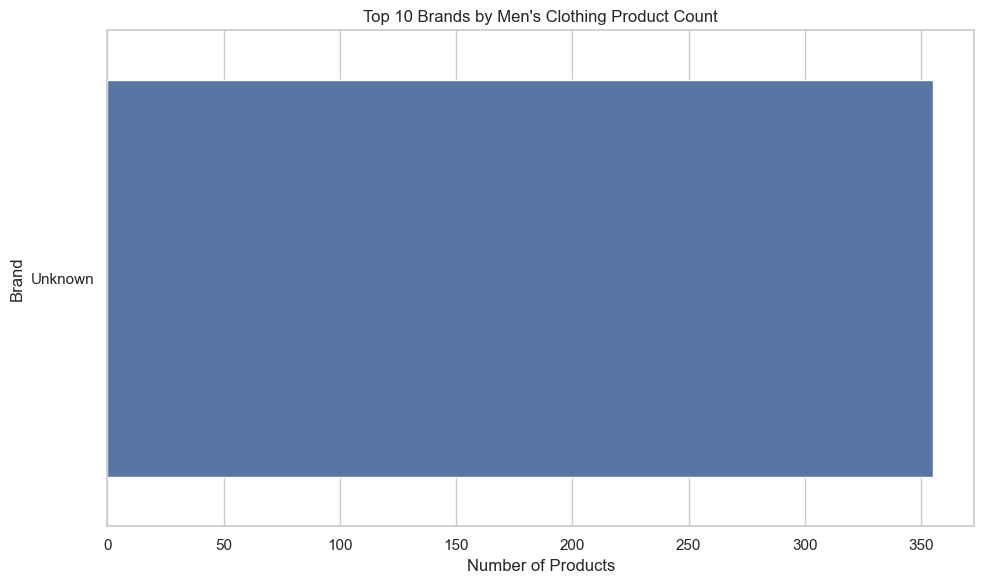

In [18]:
# Product count by brand
x = df["brand"].value_counts().head(10).sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=x.values, y=x.index)
plt.title("Top 10 Brands by Men's Clothing Product Count")
plt.xlabel("Number of Products")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()


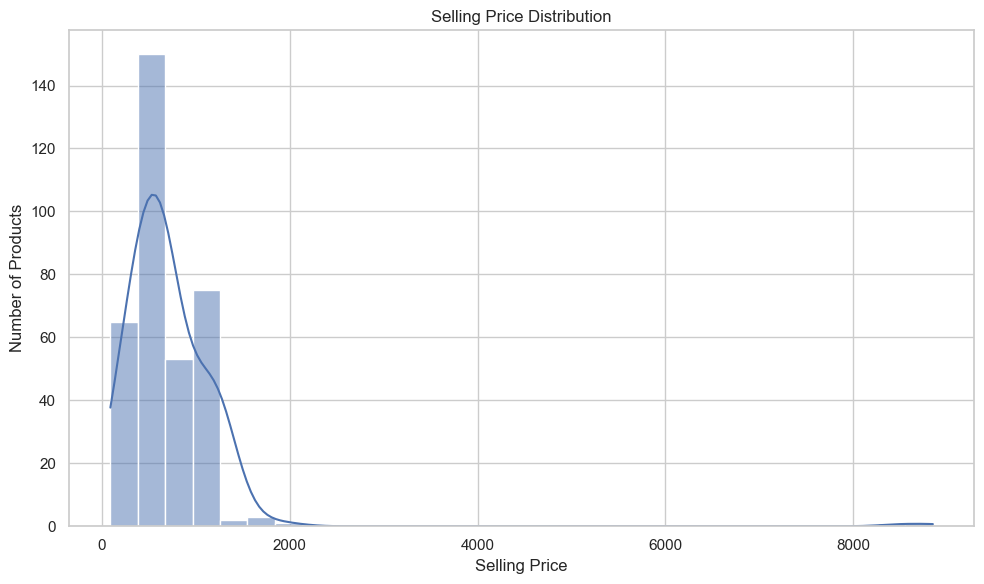

In [19]:
# Selling price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["selling_price"].dropna(), bins=30, kde=True)
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()


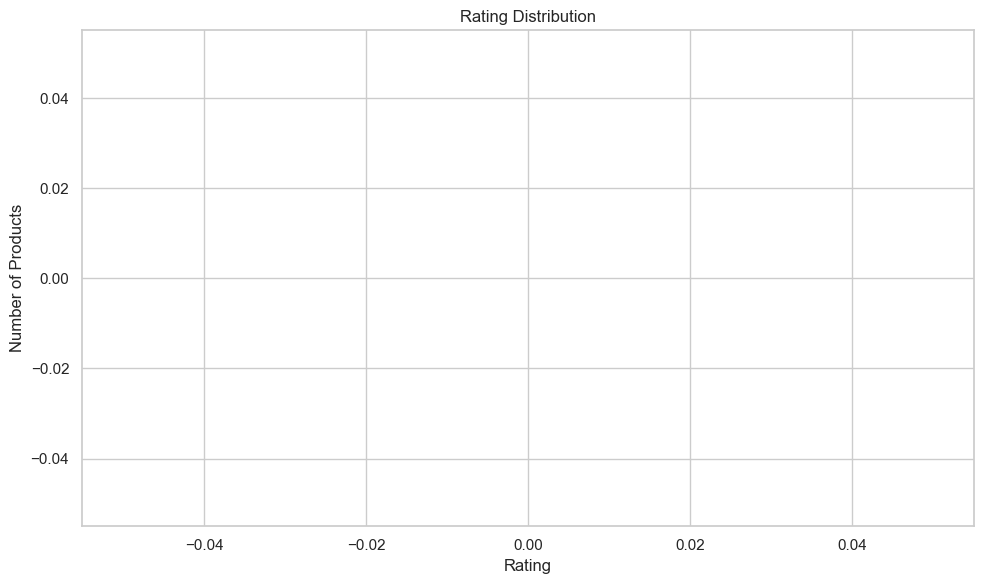

In [20]:
# Rating distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["rating"].dropna(), bins=10, discrete=True)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()


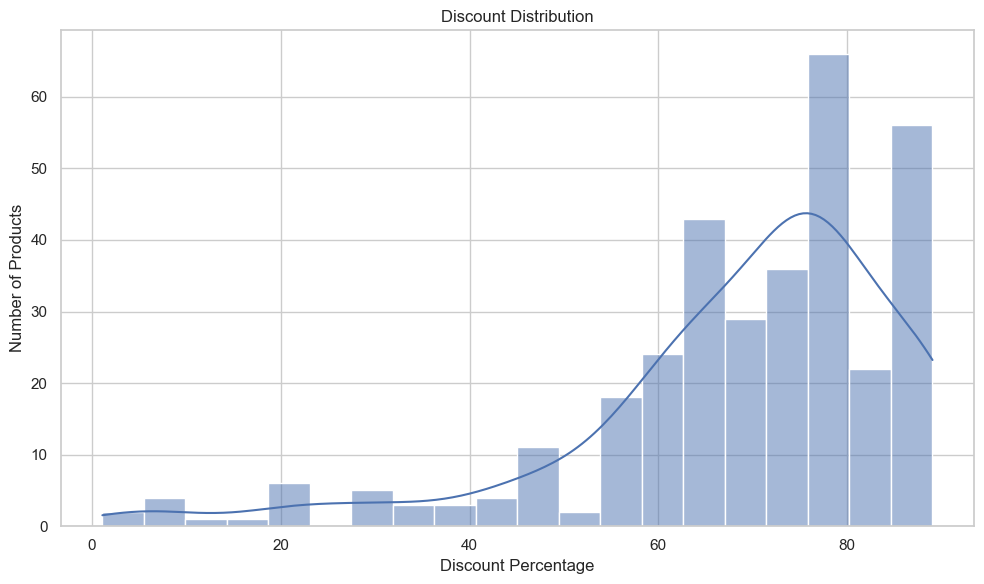

In [21]:
# Discount distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["calculated_discount_pct"].dropna(), bins=20, kde=True)
plt.title("Discount Distribution")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.show()


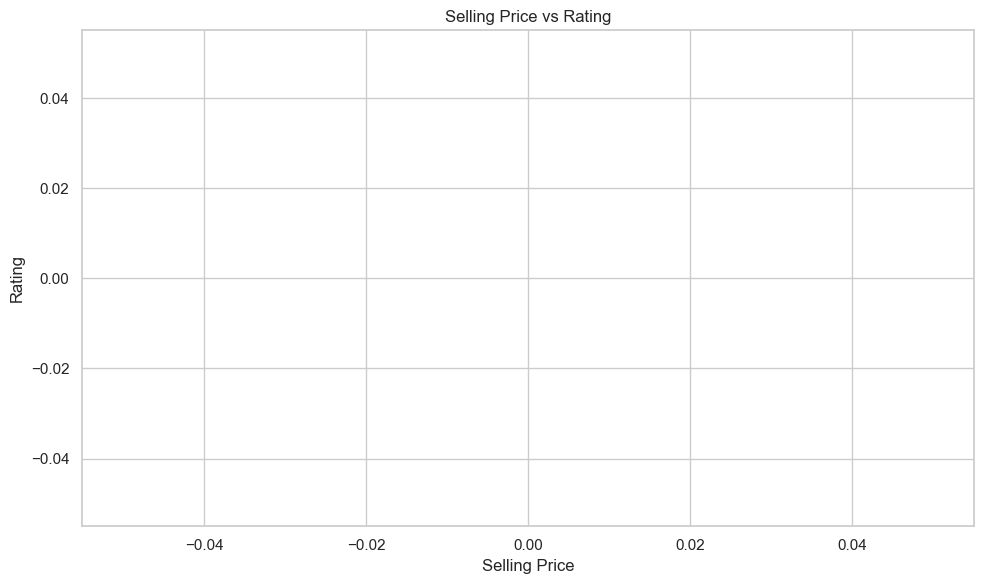

In [22]:
# Price vs rating
x = df.dropna(subset=["selling_price", "rating"])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=x, x="selling_price", y="rating", alpha=0.6)
plt.title("Selling Price vs Rating")
plt.xlabel("Selling Price")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()


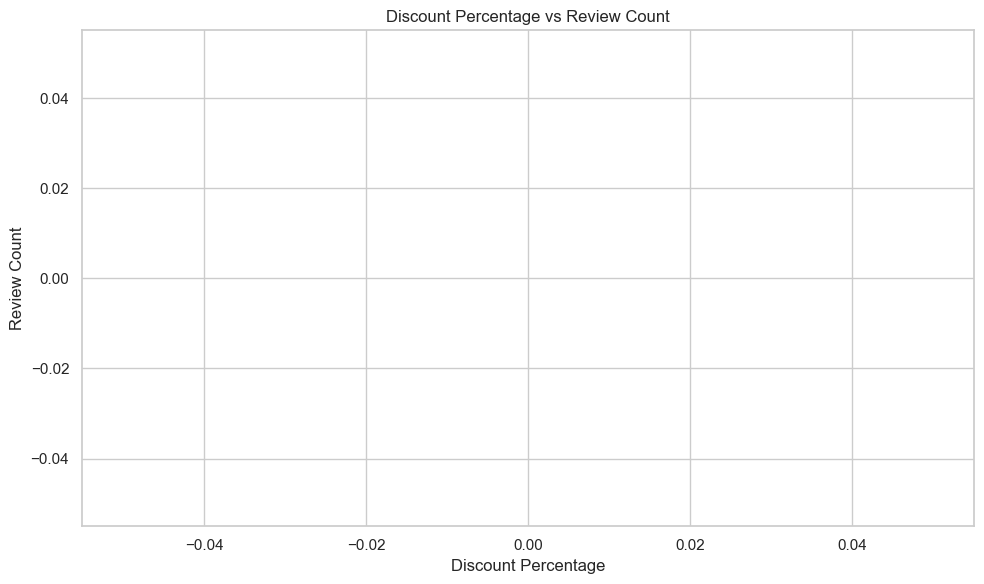

In [23]:
# Discount vs review count
x = df.dropna(subset=["calculated_discount_pct", "review_count"])

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=x,
    x="calculated_discount_pct",
    y="review_count",
    alpha=0.6
)
plt.title("Discount Percentage vs Review Count")
plt.xlabel("Discount Percentage")
plt.ylabel("Review Count")
plt.tight_layout()
plt.show()


## 18. SQL Analysis

In [24]:
conn = sqlite3.connect(":memory:")

sql_df = df.copy()

for col in sql_df.columns:
    if isinstance(sql_df[col].dtype, pd.CategoricalDtype):
        sql_df[col] = sql_df[col].astype(str)

sql_df.to_sql(
    "shopclues_mens_clothing",
    conn,
    if_exists="replace",
    index=False
)

queries = {
    "Top 10 expensive products": '''
        SELECT product_name, brand, selling_price
        FROM shopclues_mens_clothing
        WHERE selling_price IS NOT NULL
        ORDER BY selling_price DESC
        LIMIT 10
    ''',

    "Top 10 discounted products": '''
        SELECT product_name, brand, calculated_discount_pct
        FROM shopclues_mens_clothing
        WHERE calculated_discount_pct IS NOT NULL
        ORDER BY calculated_discount_pct DESC
        LIMIT 10
    ''',

    "Brand-wise product count": '''
        SELECT brand, COUNT(*) AS product_count
        FROM shopclues_mens_clothing
        GROUP BY brand
        ORDER BY product_count DESC
    ''',

    "Brand-wise average rating": '''
        SELECT brand,
               AVG(rating) AS average_rating,
               COUNT(rating) AS rated_products
        FROM shopclues_mens_clothing
        WHERE rating IS NOT NULL
        GROUP BY brand
        HAVING COUNT(rating) >= 2
        ORDER BY average_rating DESC
    ''',

    "Rating above 4": '''
        SELECT product_name, brand, rating
        FROM shopclues_mens_clothing
        WHERE rating > 4
        ORDER BY rating DESC
    ''',

    "Discount above 50 percent": '''
        SELECT product_name, brand, calculated_discount_pct
        FROM shopclues_mens_clothing
        WHERE calculated_discount_pct > 50
        ORDER BY calculated_discount_pct DESC
    ''',

    "Top reviewed products": '''
        SELECT product_name, brand, review_count
        FROM shopclues_mens_clothing
        WHERE review_count IS NOT NULL
        ORDER BY review_count DESC
        LIMIT 10
    '''
}

for title, query in queries.items():
    print("\n" + "=" * 65)
    print(title)
    print("=" * 65)
    display(pd.read_sql_query(query, conn).head(20))



Top 10 expensive products


,product_name,brand,selling_price
0,YISHAE Pure Leather Dual Tone Maroon Colored J...,Unknown,8849.0
1,WLF Pure Leather Jacket Midnight Navy Coloured...,Unknown,8499.0
2,Kaasan Men's Stretchable Regular Fit Beige Jeans,Unknown,1999.0
3,PrintCultr Men Silk Blend Green Kurta Pyjama E...,Unknown,1799.0
4,Mens kurta,Unknown,1699.0
5,Ciderboys Men's Stretch damaged Denim Slim Fit...,Unknown,1580.0
6,Men's Regular Fit Blue Jeans,Unknown,1449.0
7,Eastern Club Sweat Waist Fat Burner Body Slimm...,Unknown,1259.0
8,PrintCultr Men Solid Tuxedo Style Formal Blaze...,Unknown,1249.0
9,PrintCultr PrintCultr Men Printed Single Breas...,Unknown,1249.0



Top 10 discounted products


,product_name,brand,calculated_discount_pct
0,PrintCulture Men Solid Multicolor Cotton Blend...,Unknown,89.042308
1,PrintCulture Men Printed Pink Cotton Blend Neh...,Unknown,89.042308
2,PrintCulture Men Printed Multicolor Cotton Ble...,Unknown,89.042308
3,PrintCulture Men Solid Grey Cotton Blend Nehru...,Unknown,89.042308
4,PrintCulture Men Solid Brown Cotton Blend Nehr...,Unknown,89.042308
5,PrintCulture Men Solid Blue Cotton Blend Nehru...,Unknown,89.042308
6,PrintCulture Men Solid Black Cotton Blend Nehr...,Unknown,89.042308
7,PrintCulture Men Self Design Light Blue Cotton...,Unknown,89.042308
8,PrintCulture Men Printed Multicolor Cotton Ble...,Unknown,89.042308
9,PrintCulture Men Solid Beige Cotton Blend Nehr...,Unknown,89.042308



Brand-wise product count


...

,product_name,brand,rating



Discount above 50 percent


,product_name,brand,calculated_discount_pct
0,PrintCulture Men Solid Multicolor Cotton Blend...,Unknown,89.042308
1,PrintCulture Men Printed Pink Cotton Blend Neh...,Unknown,89.042308
2,PrintCulture Men Printed Multicolor Cotton Ble...,Unknown,89.042308
3,PrintCulture Men Solid Grey Cotton Blend Nehru...,Unknown,89.042308
4,PrintCulture Men Solid Brown Cotton Blend Nehr...,Unknown,89.042308
5,PrintCulture Men Solid Blue Cotton Blend Nehru...,Unknown,89.042308
6,PrintCulture Men Solid Black Cotton Blend Nehr...,Unknown,89.042308
7,PrintCulture Men Self Design Light Blue Cotton...,Unknown,89.042308
8,PrintCulture Men Printed Multicolor Cotton Ble...,Unknown,89.042308
9,PrintCulture Men Solid Beige Cotton Blend Nehr...,Unknown,89.042308



Top reviewed products


,product_name,brand,review_count


## 19. Data Quality Report

In [25]:
quality_report = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_count": [df[c].isna().sum() for c in df.columns],
    "missing_percent": [
        round(df[c].isna().mean() * 100, 2)
        for c in df.columns
    ],
    "unique_count": [
        df[c].nunique(dropna=True)
        for c in df.columns
    ]
})

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())

display(quality_report)

quality_report.to_csv(
    OUTPUT_DIR / "shopclues_mens_clothing_quality_report.csv",
    index=False
)


Rows: 355
Columns: 18
Duplicate rows: 0


,column,dtype,missing_count,missing_percent,unique_count
0,product_id,str,0,0.00,355
1,product_name,str,0,0.00,224
2,product_url,str,0,0.00,355
3,category,str,0,0.00,1
4,subcategory,object,0,0.00,1
5,brand,object,0,0.00,1
6,original_price,float64,19,5.35,42
7,selling_price,float64,4,1.13,71
8,discount,float64,19,5.35,56
9,rating,float64,355,100.00,0


## 20. Business Insights / Conclusion

Write conclusions only from the actual dataset.

Cover:
- Most represented brands
- Average and median selling price
- Highest discounted products
- Most reviewed products
- Highly rated brands/products
- Price vs rating relationship
- Discount vs review relationship
- Missing-data limitations
- Scraping limitations

Do not treat correlation as proof of causation.


## 21. Close Browser

In [ ]:
# Run after all work is complete:
# driver.quit()
